# T4 · Finite transitions

| | |
| --- | --- |
| **Paper** | Section 5, Eqs. (21)–(27); Appendix F. |
| **Prerequisites** | T2; Taylor expansion; quadrature. |
| **Input units** | speed mph, acceleration m/s² (converted inside), duration s for reporting and h inside emission integrals. |
| **Expected outputs** | Time and distance preservation; the 9/140 coefficient by quadrature; the admissible band; the speed-only correction kept separate from the operating-mode term. |
| **Conditions** | Symmetric kernel; cubic speed-only rate; both transitions fit inside the link (Eq. 26). The operating-mode (acceleration) part needs acceleration-dependent rates and is not computed from the speed-only table. |

Template: question, assumptions, derivation, worked example, figure, interpretation question.

## 1. Question
Real vehicles decelerate into the queue and accelerate out of it. How does a finite transition change emissions, and when do both transitions fit inside the link?

## 2. Assumptions
A transition of duration $T$ between $v_1$ and $v_2$ follows $v=v_1+(v_2-v_1)h(\xi)$ with $h(\xi)=3\xi^2-2\xi^3$, peak magnitude $a=\tfrac32|\Delta v|/T$. Travel time and distance of the traversal are preserved.

## 3. Derivation
$\int_0^1h\,d\xi=\tfrac12$, so the transition covers $(v_1+v_2)T/2$, the same as $T/2$ at each speed. Replacing the instantaneous switch therefore changes only the emission. For a cubic rate (Eq. 23):
$$\delta e=-\tfrac{9}{140}\,T\,(\Delta v)^2\,r''(\bar v),\qquad \bar v=\tfrac{v_1+v_2}2 .$$
Each transition takes half its duration from each portion, so both portions must last at least $(T_\downarrow+T_\uparrow)/2$ (Eq. 26):
$$\frac{(v_f-v_q)(T_\downarrow+T_\uparrow)}{2v_f}\le w\le L\Big(\frac1{v_q}-\frac1{v_f}\Big)-\frac{(v_f-v_q)(T_\downarrow+T_\uparrow)}{2v_q}.$$
This is the speed-only part. The operating-mode part (acceleration-dependent emission) requires acceleration-dependent rates and is not computed from the speed-only table. Section 6.6 of the paper compares the kernel with measured platoon transitions at low speeds (about 8.5–21 mph); the 46.5 mph reference traversal lies outside that measured support.

In [1]:
import sys
from pathlib import Path
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src' / 'qvdfe').exists())
sys.path.insert(0, str(ROOT / 'src'))          # works with or without `pip install -e .`
import json
import numpy as np
import matplotlib.pyplot as plt
import qvdfe
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 10})

def check(name, ok):
    print(('PASS  ' if ok else 'FAIL  ') + name)
    assert ok, name
RATES = qvdfe.load_rates()

## 4. Worked example
The detector-78 reference state of Appendix F with peak magnitudes 1.5 and 1.0 m/s².

In [2]:
from qvdfe.data import load_reference_state
ref = load_reference_state()
L, vf, vq = ref['L_mi'], ref['vf_mph'], ref['vq_mph']
Td_s, Tu_s = qvdfe.transition_time_s(vf - vq, 1.5), qvdfe.transition_time_s(vf - vq, 1.0)
print(f'T_down = {Td_s:.2f} s, T_up = {Tu_s:.2f} s')
xi = np.linspace(0, 1, 100001); h = qvdfe.kernel(xi)
check('distance preserved: integral of h = 1/2', np.isclose(np.trapezoid(h, xi), 0.5, rtol=1e-9))
check('peak of h-prime is 3/2', np.isclose(qvdfe.kernel_prime(xi).max(), 1.5, rtol=1e-9))
for p in qvdfe.POLLUTANTS:
    c = RATES[p]['coef']; T = Td_s / 3600
    v = vf + (vq - vf) * h
    quad = T * np.trapezoid(qvdfe.cubic_rate(v, c), xi) - T / 2 * (qvdfe.cubic_rate(vf, c) + qvdfe.cubic_rate(vq, c))
    closed = qvdfe.speed_only_correction(T, vf, vq, c)
    check(f'{p}: quadrature {quad:.6g} g equals -(9/140) T dv^2 r\'\' = {closed:.6g} g', np.isclose(quad, closed, rtol=1e-6, atol=1e-12))
lo, hi = qvdfe.transition_band(L, vf, vq, Td_s / 3600, Tu_s / 3600)
print(f'band {lo*60:.3f} to {hi*60:.3f} min; mean delay {ref["mean_delay_h"]*60:.3f} min; peak delay {ref["peak_delay_h"]*60:.3f} min')
check('mean-delay vehicle is admitted', lo <= ref['mean_delay_h'] <= hi)
check('peak-delay vehicle is not admitted', not (lo <= ref['peak_delay_h'] <= hi))
print('Baseline (Eq. 9) admits the peak-delay vehicle:', bool(qvdfe.finite_link_ok(ref['peak_delay_h'], L, vf, vq)),
      '-> baseline feasibility and transition feasibility are different conditions.')

T_down = 20.79 s, T_up = 31.19 s
PASS  distance preserved: integral of h = 1/2
PASS  peak of h-prime is 3/2
PASS  CO2: quadrature -5.88846 g equals -(9/140) T dv^2 r'' = -5.88846 g
PASS  NOx: quadrature -0.011346 g equals -(9/140) T dv^2 r'' = -0.011346 g
PASS  CO: quadrature -0.0138036 g equals -(9/140) T dv^2 r'' = -0.0138036 g
PASS  HC: quadrature -0.000681498 g equals -(9/140) T dv^2 r'' = -0.000681498 g
band 0.314 to 1.421 min; mean delay 0.836 min; peak delay 1.825 min
PASS  mean-delay vehicle is admitted
PASS  peak-delay vehicle is not admitted
Baseline (Eq. 9) admits the peak-delay vehicle: True -> baseline feasibility and transition feasibility are different conditions.


## 5. Figure

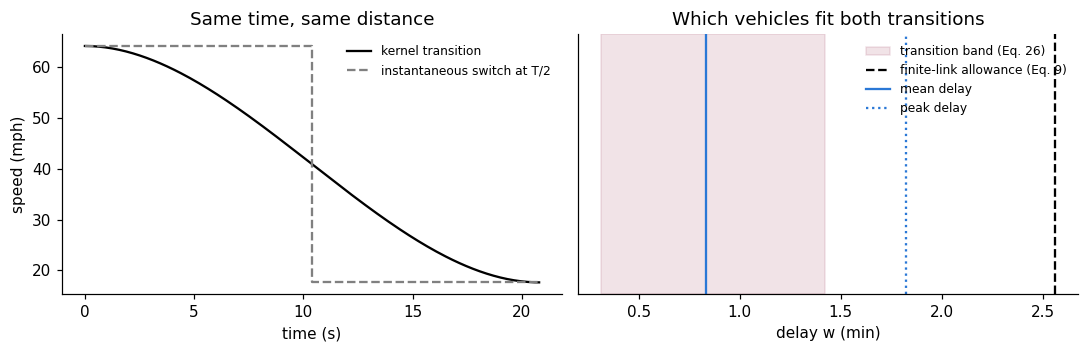

In [3]:
ts = np.linspace(0, Td_s, 200)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.3))
ax[0].plot(ts, vf + (vq - vf) * qvdfe.kernel(ts / Td_s), color='k', label='kernel transition')
ax[0].step([0, Td_s / 2, Td_s], [vf, vq, vq], where='post', color='grey', ls='--', label='instantaneous switch at T/2')
ax[0].set(xlabel='time (s)', ylabel='speed (mph)', title='Same time, same distance'); ax[0].legend(frameon=False, fontsize=8)
ws = np.linspace(0, qvdfe.finite_link_allowance(L, vf, vq) * 1.1, 200)
ax[1].axvspan(lo * 60, hi * 60, color='#8C1D40', alpha=.12, label='transition band (Eq. 26)')
ax[1].axvline(qvdfe.finite_link_allowance(L, vf, vq) * 60, color='k', ls='--', label='finite-link allowance (Eq. 9)')
ax[1].axvline(ref['mean_delay_h'] * 60, color='#2a78d6', label='mean delay'); ax[1].axvline(ref['peak_delay_h'] * 60, color='#2a78d6', ls=':', label='peak delay')
ax[1].set(xlabel='delay w (min)', yticks=[], title='Which vehicles fit both transitions'); ax[1].legend(frameon=False, fontsize=8)
plt.tight_layout()

## 6. Interpretation question
For a closed episode the delay is zero at onset and clearance, while the band needs $w\ge w_{\rm lo}>0$. Why can the admitted share never reach 100 %, and why should the admitted subset use its own $D_{\mathcal A}$ and $\bar w_{\mathcal A}$ rather than the episode mean delay? (Example 3 works this out on a long average-weekday episode whose cohort is reconstructed from its fitted delay profile.)